In [4]:
import pandas as pd
import numpy as np
import re
import os
import tempfile
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
import tempfile
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
results_dir = "results"

if not os.access(".", os.W_OK):
    tmp_dir = tempfile.mkdtemp(prefix="notebook_results_")
    print(f"Working directory not writable. Switching to temp directory: {tmp_dir}")
    os.chdir(tmp_dir)

os.makedirs(results_dir, exist_ok=True)
results_dir = "results"
try:
	os.makedirs(results_dir, exist_ok=True)
except OSError:
	results_dir = os.path.join(tempfile.gettempdir(), "results")
	os.makedirs(results_dir, exist_ok=True)

Working directory not writable. Switching to temp directory: /var/folders/_2/rq5p5nrn5h74n6s2m7pn0_m40000gn/T/notebook_results_y59wwazh


In [5]:
df = pd.read_csv("/Users/umeshkapil/Downloads/ai_project_synthetic_datasets/part_3_nlp_sequence_modeling/customer_support_text_classification.csv")

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [6]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Classes:")
print(df["sentiment_label"].unique())

print("\nClass Distribution:")
print(df["sentiment_label"].value_counts())

print("\nAverage Text Length:")
print(df["customer_message"].str.split().str.len().mean())

print("\nSample Text Records:")
print(df[["customer_message", "sentiment_label"]].head())

Dataset Shape:
(1500, 6)

Column Names:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='str')

Missing Values:
ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0
dtype: int64

Target Classes:
<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Average Text Length:
12.722666666666667

Sample Text Records:
                                    customer_message sentiment_label
0  I need information about the payment process. ...         neutral
1      I need information about the payment process.         neutral
2  The refund process was fast and convenient. I ...        positive
3  My refund is still pending and this experience...        negative
4   Please tell me how to update my account details.         neu

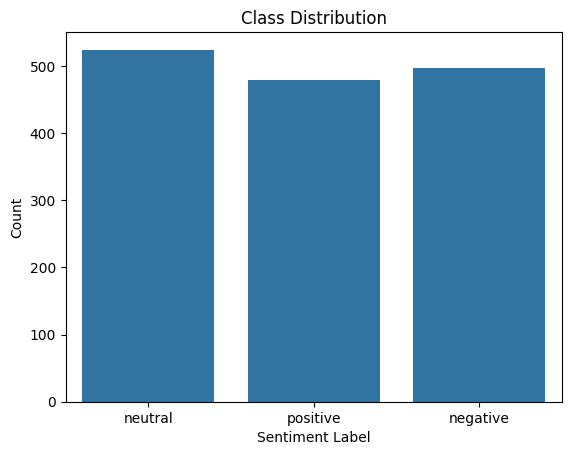

In [7]:
sns.countplot(x="sentiment_label", data=df)

plt.title("Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")

plt.show()

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_message"] = df["customer_message"].apply(clean_text)

df[["customer_message", "clean_message"]].head()

,customer_message,clean_message
0,I need information about the payment process. ...,i need information about the payment process m...
1,I need information about the payment process.,i need information about the payment process
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient i a...
3,My refund is still pending and this experience...,my refund is still pending and this experience...
4,Please tell me how to update my account details.,please tell me how to update my account details


In [9]:
label_encoder = LabelEncoder()

df["label_encoded"] = label_encoder.fit_transform(df["sentiment_label"])

print("Label Mapping:")
for class_name, encoded_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(class_name, ":", encoded_value)

Label Mapping:
negative : 0
neutral : 1
positive : 2


In [10]:
X = df["clean_message"]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Records:", X_train.shape[0])
print("Testing Records:", X_test.shape[0])

Training Records: 1200
Testing Records: 300


In [11]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape:", X_test_tfidf.shape)

TF-IDF Training Shape: (1200, 132)
TF-IDF Testing Shape: (300, 132)


In [12]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_tfidf, y_train)

baseline_predictions = baseline_model.predict(X_test_tfidf)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline Model Accuracy:", baseline_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    baseline_predictions,
    target_names=label_encoder.classes_
))

Baseline Model Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



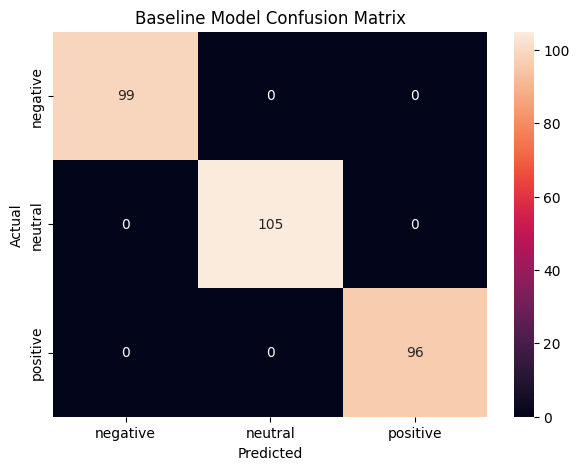

In [13]:
cm = confusion_matrix(y_test, baseline_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Baseline Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("results/confusion_matrix.png")

plt.show()

In [14]:
max_words = 5000
max_length = 40

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Padded Training Shape:", X_train_padded.shape)
print("Padded Testing Shape:", X_test_padded.shape)

Padded Training Shape: (1200, 40)
Padded Testing Shape: (300, 40)


In [15]:
lstm_model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=64,
        input_length=max_length
    ),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = lstm_model.fit(
    X_train_padded,
    y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3531 - loss: 1.1001 - val_accuracy: 0.3375 - val_loss: 1.1012
Epoch 2/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4260 - loss: 1.0821 - val_accuracy: 0.6292 - val_loss: 0.8449
Epoch 3/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6708 - loss: 0.7713 - val_accuracy: 0.5500 - val_loss: 0.6909
Epoch 4/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6479 - loss: 0.6324 - val_accuracy: 0.6417 - val_loss: 0.6205
Epoch 5/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6833 - loss: 0.5266 - val_accuracy: 0.6958 - val_loss: 0.4658
Epoch 6/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6458 - loss: 0.4740 - val_accuracy: 0.6417 - val_loss: 0.4656
Epoch 7/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6854 - loss: 0.4589 - val_accuracy: 0.6417 - val_loss: 0.4709
Epoch 8/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6802 - loss: 0.4598 - val_accuracy: 0.6958 - val_loss: 0

In [17]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_padded, y_test)

print("LSTM Test Loss:", lstm_loss)
print("LSTM Test Accuracy:", lstm_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6700 - loss: 0.4538
LSTM Test Loss: 0.4537898898124695
LSTM Test Accuracy: 0.6700000166893005


In [18]:
evaluation_results = pd.DataFrame({
    "Model": ["Logistic Regression with TF-IDF", "LSTM Sequence Model"],
    "Accuracy": [baseline_accuracy, lstm_accuracy]
})

evaluation_results.to_csv("results/model_evaluation.csv", index=False)

evaluation_results

,Model,Accuracy
0,Logistic Regression with TF-IDF,1.00
1,LSTM Sequence Model,0.67


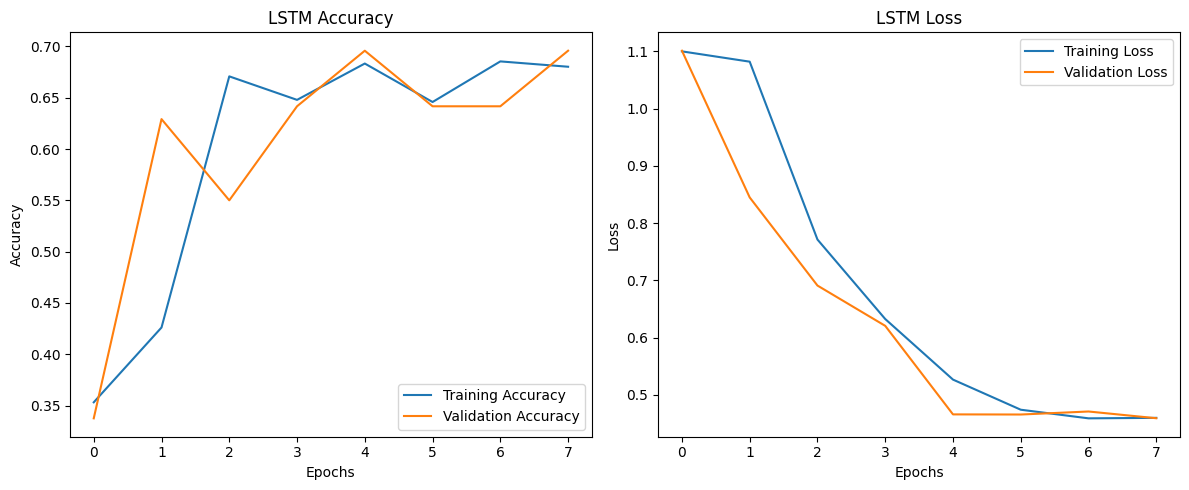

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("results/model_evaluation.png")
plt.show()

In [20]:
sample_texts = X_test.head(10)

sample_tfidf = tfidf.transform(sample_texts)

sample_predictions = baseline_model.predict(sample_tfidf)

sample_prediction_labels = label_encoder.inverse_transform(sample_predictions)

with open("results/sample_predictions.txt", "w") as file:
    for text, prediction in zip(sample_texts, sample_prediction_labels):
        file.write("Message: " + text + "\n")
        file.write("Predicted Sentiment: " + prediction + "\n")
        file.write("-" * 50 + "\n")

print("Sample predictions saved successfully.")

Sample predictions saved successfully.
